In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Benefícios Concedidos

##### "Empilhando" o banco de dados referente aos benefícios concedidos, onde é colocada todas as colunas que aparecem nos meses (mesmo que só em 1 mês)

In [2]:
beneficios = pd.concat(pd.read_csv(f'beneficiosconcedidos ({num}).csv', sep = ";", decimal= ",") for num in range(2,50))

In [3]:
beneficios.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20131252 entries, 0 to 426459
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Competência concessão  object 
 1   Espécie                object 
 2   CID                    object 
 3   CID.1                  object 
 4   Despacho               object 
 5   Dt Nascimento          object 
 6   Sexo.                  object 
 7   Clientela              object 
 8   Mun Resid              object 
 9   Vínculo dependentes    object 
 10  Forma Filiação         object 
 11  UF                     object 
 12  Qt SM RMI              float64
 13  CID_1                  object 
 14  Tipo de Cálculo        object 
dtypes: float64(1), object(14)
memory usage: 19.0 GB


In [141]:
beneficios

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Sexo.,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo
0,janeiro/2019,Auxílio Doenca Previdenciário,I83,I83 Varizes dos Membros Infer,Concessao Normal,25/10/1967,Feminino,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1.068,NaN,NaN
1,janeiro/2019,Auxílio Doenca Previdenciário,S525,S52.5 Frat da Extremidade Distal do Radio,Conc. Base Artigo 27 Inciso Ii do Rbps,16/05/1994,Masculino,Urbano,02003-AL-Arapiraca,Não Informado,Empregado,Alagoas,1.099,NaN,NaN
2,janeiro/2019,Auxílio Doenca Previdenciário,N811,N81.1 Cistocele,Concessao Normal,03/03/1967,Feminino,Urbano,02003-AL-Arapiraca,Não Informado,Autônomo,Alagoas,1.000,NaN,NaN
3,janeiro/2019,Auxílio Doenca Previdenciário,O200,O20.0 Ameaca de Aborto,Concessao Normal,06/09/1986,Feminino,Urbano,02003-AL-Arapiraca,Filho,Desempregado,Alagoas,1.000,NaN,NaN
4,janeiro/2019,Auxílio Doenca Previdenciário,K80,K80 Colelitiase,Concessao Normal,23/06/1983,Feminino,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1.728,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426455,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,11/04/2012,Masculino,Urbano,28058-TO-Pindorama do Tocantins,Filho,Autônomo,Tocantins,1.000,NaN,Calculo na Dib sem Fator
426456,202212,Aposentadoria por Idade,Zerados,NaN,Concessao Normal,07/04/1961,Feminino,Urbano,28112-TO-Rio dos Bois,Não Informado,Desempregado,Tocantins,1.000,NaN,Calculo com Regras da Re
426457,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,18/01/1977,Feminino,Rural,11702-MG-Uberlândia,Cônjuge,Segurado Especial,Tocantins,1.000,NaN,Rmi Informada/Salã¡Rio M
426458,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,29/05/1955,Feminino,Rural,06118-MS-Sete Quedas,Cônjuge,Segurado Especial,Tocantins,1.000,NaN,Rmi Informada/Salã¡Rio M


Retirando uma coluna errada

In [4]:
filtro3 = beneficios['Clientela'] != '{ñ class'
beneficios = beneficios[filtro3]

Transformando as variáveis que estavam classificados como objetos em categorias

In [5]:
beneficios['Sexo.'] = beneficios['Sexo.'].replace('Masculino    ','Masculino')
beneficios['Sexo.'] = beneficios['Sexo.'].replace('Feminino     ','Feminino')

In [6]:
beneficios['Clientela'] = beneficios['Clientela'].replace('Urbano  ','Urbano')
beneficios['Clientela'] = beneficios['Clientela'].replace('Rural   ','Rural')

In [7]:
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Filho        ','Filho')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Cônjuge      ','Cônjuge')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Companheiro  ','Companheiro')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Ex-Cônjuge   ','Ex-Cônjuge')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Designado    ','Designado')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Pai/Mãe      ', 'Pai/Mãe')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].replace('Irmão        ', 'Irmão')

In [8]:
beneficios['Espécie'] = beneficios['Espécie'].replace(['Auxílio Doenca Previdenciário                ','Auxílio Doenca Previdenciário',
                                                       'Pensão Vitalícia Sindrome Talidomida         ','Pensão Vitalícia Sindrome Talidomida']
                                                       ,'Auxílio Doença Previdenciário')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Aposentadoria por Idade                      ','Aposentadoria por Velhice - Trab. Rural',
                                                       'Aposentadoria por Velhice - Trab. Rural      ','Aposent. por Idade - Empregador Rural',
                                                       'Renda Mensal Vitalícia por Idade'], 'Aposentadoria por Idade')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Auxílio Salario Maternidade','Auxílio Salario Maternidade                  ',
                                                       ], 'Auxílio Salário Maternidade')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Pensão por Morte Previdenciária              ','Pensão por Morte Acidente do Trabalho',
                                                       'Pensão por Morte Acidente do Trabalho        ','Pensão por Morte de Ex-Combatente',
                                                       'Pensão por Morte de Ex-Combatente            ','Pensão por Morte de Anistiados',
                                                       'Pensão por Morte de Trabalhador Rural','Pensão por Morte de Anistiados               ',
                                                       'Pensão por Morte de Trabalhador Rural        ','Pensão por Morte Ex-Sasse',
                                                       'Pensão por Morte Ex-Sasse                    ','Pensão por Morte Ex-Combatente Maritimo',
                                                       'Pensão Morte Servidor Público Federal        ','Pensão por Morte Estatutária',
                                                       'Pensão Morte Servidor Público Federal','Pensão por Morte Especial',
                                                       'Pensão por Morte Ex-Combatente Maritimo      '], 'Pensão por Morte Previdenciária')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Aposentadoria por Tempo de Contribuição      '],'Aposentadoria por Tempo de Contribuição')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Aposentadoria Invalidez Previdenciária       ','Aposentadoria Invalidez Previdenciária',
                                                       'Aposent. Invalidez Acidente Trabalho','Aposent. Invalidez Acidente Trabalho         ',
                                                       'Aposentadoria por Invalidez-Trab. Rural','Aposentadoria por Invalidez-Trab. Rural      ',
                                                       'Amparo Previdenc. Invalidez- Trab. Rural     ','Amparo Previdenc. Invalidez- Trab. Rural',
                                                       'Aposent. Invalidez Acidentária-Trab.Rur.','Aposent. Invalidez Acidentária-Trab.Rur.     ',
                                                       'Aposentadoria Invalidez Aeronauta'],'Aposentadoria por Invalidez Previdenciária')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Auxílio Doenca por Acidente do Trabalho','Auxílio Doenca por Acidente do Trabalho      ',
                                                       'Auxílio Acidente                             ','Auxílio Acidente',
                                                       'Auxílio Acidente Previdenciário','Auxílio Acidente Previdenciário              ',
                                                       'Auxílio Suplementar Acidente Trabalho','Auxílio Suplementar Acidente Trabalho        '
                                                       ],'Auxílio Acidente do Trabalho')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Aposentadoria Especial','Aposentadoria Especial                       ',
                                                       'Aposentadoria Especial de Aeronauta','Pensao Especial Hanseniase Lei 11520/07      ',
                                                       'Pensao Especial Hanseniase Lei 11520/07','Pensão Vitalícia Seringueiros',
                                                       'Auxilio União                                ','Auxilio União',
                                                       'Pensão Vitalícia Dependentes Seringueiro','Pensão Vitalícia Dependentes Seringueiro     ',
                                                       'Benefício Indenizatório a Cargo da União'],'Aposentadoria Especial')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Auxílio Reclusão                             '],'Auxílio Reclusão')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Aposent. Tempo de Serviço de Professor','Aposent. Tempo de Serviço de Professor       '
                                                       ],'Aposentadoria por Tempo de Serviço')

beneficios['Espécie'] = beneficios['Espécie'].replace(['Auxílio Inclusão À Pessoa com Deficiência    ','Pensão Vitalícia Seringueiros                ',
                                                       'Benefício Indenizatório a Cargo da União     ','Amparo Social ao Idoso                       ',
                                                       'Amp. Social Pessoa Portadora Deficiencia     ','Amparo Social ao Idoso',
                                                       'Amp. Social Pessoa Portadora Deficiencia','Renda Mensal Vitalícia por Incapacidade      ',
                                                       'Renda Mensal Vitalícia por Incapacidade'],)

In [25]:
beneficios['Espécie'].value_counts()

Auxílio Doença Previdenciário                 8619432
Aposentadoria por Idade                       3284875
Auxílio Salário Maternidade                   2700215
Pensão por Morte Previdenciária               2208227
Aposentadoria por Tempo de Contribuição       1347558
Auxílio Acidente do Trabalho                   783887
Aposentadoria por Invalidez Previdenciária     777565
Aposentadoria Especial                         309844
Auxílio Reclusão                                58943
Aposentadoria por Tempo de Serviço              40683
Name: Espécie, dtype: int64

In [9]:
beneficios['Espécie'] = beneficios['Espécie'].astype("category")
beneficios['CID'] = beneficios['CID'].astype("category")
beneficios['Despacho'] = beneficios['Despacho'].astype('category')
beneficios['Sexo.'] = beneficios['Sexo.'].astype('category')
beneficios['Clientela'] = beneficios['Clientela'].astype('category')
beneficios['Mun Resid'] = beneficios['Mun Resid'].astype('category')
beneficios['Vínculo dependentes'] = beneficios['Vínculo dependentes'].astype('category')
beneficios['Forma Filiação'] = beneficios['Forma Filiação'].astype('category')
beneficios['UF'] = beneficios['UF'].astype('category')
beneficios['CID.1'] = beneficios['CID.1'].astype('category')
beneficios['Tipo de Cálculo'] = beneficios['Tipo de Cálculo'].astype('category')
beneficios['CID_1'] = beneficios['CID_1'].astype('category')

In [156]:
beneficios['Clientela'].value_counts()

Urbano    13710918
Rural      2755688
Name: Clientela, dtype: int64

In [10]:
beneficios['Sexo'] = beneficios['Sexo.']
beneficios.drop(["Sexo."], axis=1, inplace=True)

In [11]:
beneficios["Qt SM RMI"] = beneficios["Qt SM RMI"].astype(np.int16)

In [10]:
beneficios['Dt Nascimento'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20131252 entries, 0 to 20131251
Series name: Dt Nascimento
Non-Null Count     Dtype 
--------------     ----- 
20131242 non-null  object
dtypes: object(1)
memory usage: 153.6+ MB


Codigo para trocar simbolo no meio de um conjunto de palavras

In [32]:
#beneficios['Dt Nascimento'] = beneficios['Dt Nascimento'].str.replace("-","/")

Removendo Valores Ausentes da Coluna Data de Nascimento

In [18]:
beneficios["Dt Nascimento"].isnull().sum().sum()

10

In [19]:
beneficios["Competência concessão"].isnull().sum().sum()

0

In [20]:
beneficios['Clientela'].isnull().sum().sum()

3664645

In [12]:
aus = pd.notnull(beneficios["Dt Nascimento"])
beneficios = beneficios[aus]

In [84]:
beneficios[beneficios['Dt Nascimento'].str.contains("{ñ class}")]

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Sexo.,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo
364119,março/2019,Pensão por Morte Previdenciária,000000,Zerados,Concessao Decorrente de Acao Judicial,{ñ class},Feminino,Rural,28059-TO-Pium,Companheiro,Segurado Especial,Tocantins,1,NaN,NaN
282073,abril/2019,Pensão Vitalícia Dependentes Seringueiro,000000,Zerados,Concessao Decorrente de Acao Judicial,{ñ class},Masculino,Urbano,24004-AC-Cruzeiro do Sul,Cônjuge,Desempregado,Acre,2,NaN,NaN
293627,abril/2019,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,Urbano,05043-CE-Crato,Cônjuge,Autônomo,Ceará,1,NaN,NaN
141542,201905,Auxílio Doenca Previdenciário,,Em Branco,Concessao Decorrente de Acao Judicial,{ñ class},Masculino,NaN,21232-SP-Itaquaquecetuba,Não Informado,Desempregado,São Paulo,1,NaN,NaN
323639,201907,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,NaN,13076-PB-João Pessoa,Cônjuge,Empregado,Paraíba,2,NaN,NaN
199886,201908,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,NaN,11701-MG-Uberaba,Companheiro,Autônomo,Minas Gerais,1,NaN,NaN
221188,201908,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,NaN,15096-PE-Olinda,Cônjuge,Empregado,Pernambuco,2,NaN,NaN
140549,201909,Auxílio Doenca Previdenciário,F31,F31 Transt Afetivo Bipolar,Concessao Normal,{ñ class},Masculino,NaN,11791-MG-Franciscópolis,Filho,Empregado,Minas Gerais,5,NaN,NaN
520705,201910,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,NaN,08049-GO-Campos Belos,Cônjuge,Desempregado,Roraima,2,NaN,NaN
292950,201912,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,{ñ class},Feminino,NaN,26017-RO-Alvorada d Oeste,Companheiro,Empregado,Mato Grosso,1,NaN,NaN


In [12]:
beneficios[beneficios['Dt Nascimento'].str.contains('00/01/1900')]

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo
53757,202101,Auxílio Doença Previdenciário,S634,NaN,Conc. Base Artigo 27 Inciso Ii do Rbps,00/01/1900,Urbano,21263-SP-Juquitiba,Não Informado,Empregado,São Paulo,5,S63.4 Rupt Traum Lig Dedo Artic Metacarp Inte,NaN,Masculino


In [13]:
filtro = beneficios['Dt Nascimento'] != "{ñ class}"
beneficios = beneficios[filtro]

In [14]:
filtro2 = beneficios['Dt Nascimento'] != '00/01/1900'
beneficios = beneficios[filtro2]

In [15]:
beneficios = beneficios.reset_index(drop=True)
beneficios

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo
0,janeiro/2019,Auxílio Doença Previdenciário,I83,I83 Varizes dos Membros Infer,Concessao Normal,25/10/1967,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1,NaN,NaN,Feminino
1,janeiro/2019,Auxílio Doença Previdenciário,S525,S52.5 Frat da Extremidade Distal do Radio,Conc. Base Artigo 27 Inciso Ii do Rbps,16/05/1994,Urbano,02003-AL-Arapiraca,Não Informado,Empregado,Alagoas,1,NaN,NaN,Masculino
2,janeiro/2019,Auxílio Doença Previdenciário,N811,N81.1 Cistocele,Concessao Normal,03/03/1967,Urbano,02003-AL-Arapiraca,Não Informado,Autônomo,Alagoas,1,NaN,NaN,Feminino
3,janeiro/2019,Auxílio Doença Previdenciário,O200,O20.0 Ameaca de Aborto,Concessao Normal,06/09/1986,Urbano,02003-AL-Arapiraca,Filho,Desempregado,Alagoas,1,NaN,NaN,Feminino
4,janeiro/2019,Auxílio Doença Previdenciário,K80,K80 Colelitiase,Concessao Normal,23/06/1983,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1,NaN,NaN,Feminino
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20131224,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,11/04/2012,Urbano,28058-TO-Pindorama do Tocantins,Filho,Autônomo,Tocantins,1,NaN,Calculo na Dib sem Fator,Masculino
20131225,202212,Aposentadoria por Idade,Zerados,NaN,Concessao Normal,07/04/1961,Urbano,28112-TO-Rio dos Bois,Não Informado,Desempregado,Tocantins,1,NaN,Calculo com Regras da Re,Feminino
20131226,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,18/01/1977,Rural,11702-MG-Uberlândia,Cônjuge,Segurado Especial,Tocantins,1,NaN,Rmi Informada/Salã¡Rio M,Feminino
20131227,202212,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,29/05/1955,Rural,06118-MS-Sete Quedas,Cônjuge,Segurado Especial,Tocantins,1,NaN,Rmi Informada/Salã¡Rio M,Feminino


Transformando no tipo data

In [16]:
beneficios["Dt Nascimento"] = pd.to_datetime(beneficios["Dt Nascimento"], format="%d/%m/%Y")

Calculando a Idade, apartir da Data de Nascimento e Criando uma Nova Coluna Idade

In [17]:
from datetime import datetime, date

def age(born):
    today = date.today()
    return today.year - born.year - ((today.month,today.day) < (born.month,born.day))

beneficios['Idade'] = beneficios['Dt Nascimento'].apply(age)

In [18]:
beneficios["Competência concessão"] = beneficios["Competência concessão"].replace("janeiro/2019","201901")
beneficios["Competência concessão"] = beneficios["Competência concessão"].replace("fevereiro/2019","201902")
beneficios["Competência concessão"] = beneficios["Competência concessão"].replace("março/2019","201903")
beneficios["Competência concessão"] = beneficios["Competência concessão"].replace("abril/2019","201904")

In [20]:
beneficios["Competência concessão"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 20131230 entries, 0 to 20131229
Series name: Competência concessão
Non-Null Count     Dtype 
--------------     ----- 
20131230 non-null  object
dtypes: object(1)
memory usage: 153.6+ MB


In [19]:
beneficios['Competência concessão'] = pd.to_datetime(beneficios['Competência concessão'], format="%Y%m")

In [20]:
beneficios.info(memory_usage="deep") # diminuiu o espaço usado de 20 GB para 3.3 GB depois da transformação em categorias

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20131229 entries, 0 to 20131228
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Competência concessão  datetime64[ns]
 1   Espécie                category      
 2   CID                    category      
 3   CID.1                  category      
 4   Despacho               category      
 5   Dt Nascimento          datetime64[ns]
 6   Clientela              category      
 7   Mun Resid              category      
 8   Vínculo dependentes    category      
 9   Forma Filiação         category      
 10  UF                     category      
 11  Qt SM RMI              int16         
 12  CID_1                  category      
 13  Tipo de Cálculo        category      
 14  Sexo                   category      
 15  Idade                  int64         
dtypes: category(12), datetime64[ns](2), int16(1), int64(1)
memory usage: 812.8 MB


In [20]:
beneficios['Ano'] = beneficios['Competência concessão'].dt.year

In [21]:
beneficios['Ano'] = beneficios['Ano'].astype('category')

In [22]:
beneficios['Situação'] = 'concedido'
concedidos = beneficios
concedidos

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo,Idade,Ano,Situação
0,2019-01-01,Auxílio Doença Previdenciário,I83,I83 Varizes dos Membros Infer,Concessao Normal,1967-10-25,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1,NaN,NaN,Feminino,55,2019,concedido
1,2019-01-01,Auxílio Doença Previdenciário,S525,S52.5 Frat da Extremidade Distal do Radio,Conc. Base Artigo 27 Inciso Ii do Rbps,1994-05-16,Urbano,02003-AL-Arapiraca,Não Informado,Empregado,Alagoas,1,NaN,NaN,Masculino,29,2019,concedido
2,2019-01-01,Auxílio Doença Previdenciário,N811,N81.1 Cistocele,Concessao Normal,1967-03-03,Urbano,02003-AL-Arapiraca,Não Informado,Autônomo,Alagoas,1,NaN,NaN,Feminino,56,2019,concedido
3,2019-01-01,Auxílio Doença Previdenciário,O200,O20.0 Ameaca de Aborto,Concessao Normal,1986-09-06,Urbano,02003-AL-Arapiraca,Filho,Desempregado,Alagoas,1,NaN,NaN,Feminino,36,2019,concedido
4,2019-01-01,Auxílio Doença Previdenciário,K80,K80 Colelitiase,Concessao Normal,1983-06-23,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1,NaN,NaN,Feminino,39,2019,concedido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20131224,2022-12-01,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,2012-04-11,Urbano,28058-TO-Pindorama do Tocantins,Filho,Autônomo,Tocantins,1,NaN,Calculo na Dib sem Fator,Masculino,11,2022,concedido
20131225,2022-12-01,Aposentadoria por Idade,Zerados,NaN,Concessao Normal,1961-04-07,Urbano,28112-TO-Rio dos Bois,Não Informado,Desempregado,Tocantins,1,NaN,Calculo com Regras da Re,Feminino,62,2022,concedido
20131226,2022-12-01,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,1977-01-18,Rural,11702-MG-Uberlândia,Cônjuge,Segurado Especial,Tocantins,1,NaN,Rmi Informada/Salã¡Rio M,Feminino,46,2022,concedido
20131227,2022-12-01,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,1955-05-29,Rural,06118-MS-Sete Quedas,Cônjuge,Segurado Especial,Tocantins,1,NaN,Rmi Informada/Salã¡Rio M,Feminino,68,2022,concedido


In [23]:
concedidos_se = concedidos[concedidos['UF'].str.contains('Sergipe')]
concedidos_se = concedidos_se.reset_index(drop=True)
concedidos_se

,Competência concessão,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo,Idade,Ano,Situação
0,2019-01-01,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,1940-09-15,Urbano,22003-SE-Aracaju,Ex-Cônjuge,Autônomo,Sergipe,1,NaN,NaN,Feminino,82,2019,concedido
1,2019-01-01,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,1963-01-30,Urbano,22006-SE-Barra dos Coqueiros,Ex-Cônjuge,Desempregado,Sergipe,2,NaN,NaN,Feminino,60,2019,concedido
2,2019-01-01,Auxílio Doença Previdenciário,M06,M06 Outr Artrites Reumatoides,Concessao Normal,1973-03-03,Urbano,22003-SE-Aracaju,Não Informado,Empregado,Sergipe,1,NaN,NaN,Feminino,50,2019,concedido
3,2019-01-01,Auxílio Doença Previdenciário,S820,S82.0 Frat da Rotula,Conc. Base Artigo 27 Inciso Ii do Rbps,1987-06-02,Urbano,22021-SE-Estância,Não Informado,Empregado,Sergipe,2,NaN,NaN,Feminino,36,2019,concedido
4,2019-01-01,Auxílio Doença Previdenciário,S835,S83.5 Entorse Distensao Envolv Lig Cruzado Jo,Conc. Base Artigo 27 Inciso Ii do Rbps,1987-07-11,Urbano,22023-SE-Frei Paulo,Filho,Empregado,Sergipe,1,NaN,NaN,Masculino,35,2019,concedido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154351,2022-12-01,Pensão por Morte Previdenciária,Zerados,NaN,Concessao Normal,2013-02-18,Rural,22054-SE-Poço Redondo,Filho,Segurado Especial,Sergipe,1,NaN,Rmi Informada/Salã¡Rio M,Masculino,10,2022,concedido
154352,2022-12-01,Auxílio Doença Previdenciário,Em Branco,NaN,Concessao Decorrente de Acao Judicial,1964-03-10,Urbano,22040-SE-Maruim,Não Informado,Facultativo,Sergipe,1,NaN,Calculo na Dib sem Fator,Feminino,59,2022,concedido
154353,2022-12-01,Auxílio Doença Previdenciário,Em Branco,NaN,Concessao Decorrente de Acao Judicial,1978-02-05,Urbano,15116-PE-Recife,Não Informado,Desempregado,Sergipe,1,NaN,Calculo na Dib sem Fator,Feminino,45,2022,concedido
154354,2022-12-01,Auxílio Doença Previdenciário,Em Branco,NaN,Concessao Decorrente de Acao Judicial,1970-02-13,Urbano,05088-CE-Morada Nova,Não Informado,Desempregado,Sergipe,1,NaN,Calculo na Dib sem Fator,Masculino,53,2022,concedido


# Benefícios Indeferidos

In [24]:
indeferidos = pd.concat(pd.read_csv(f'beneficiosindeferidos ({num}).csv', sep = ";", decimal= ",") for num in range(2,50))
indeferidos

,Competência indeferimento,Espécie,Motivo Indeferimento,Dt Nascimento,Sexo.,Clientela,Forma Filiação,UF,Dt Indeferimento
0,janeiro/2019,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,02/05/1963,Feminino,Urbano,Desempregado,Alagoas,02/01/2019
1,janeiro/2019,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,12/07/1967,Masculino,Urbano,Desempregado,Alagoas,02/01/2019
2,janeiro/2019,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,01/01/1966,Masculino,Urbano,Desempregado,Alagoas,02/01/2019
3,janeiro/2019,Auxílio Salario Maternidade,Parto/Guarda para Fins Adocao sem Qualidade de...,03/03/1978,Feminino,Urbano,Doméstico,Alagoas,04/01/2019
4,janeiro/2019,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,04/02/1966,Masculino,Urbano,Desempregado,Alagoas,04/01/2019
...,...,...,...,...,...,...,...,...,...
423578,202212,Amp. Social Pessoa Portadora Deficiencia,Nao Cumprimento de Exigencias,10/11/1968,Masculino,Urbano,Desempregado,Tocantins,31/12/2022
423579,202212,Aposentadoria por Idade,Falta Período Carencia não Comprv Ativ Rural,16/06/1963,Feminino,Urbano,Desempregado,Tocantins,31/12/2022
423580,202212,Auxílio Salario Maternidade,Req nao Fil Rgps Dt Nascim,31/10/1994,Feminino,Rural,Segurado Especial,Tocantins,31/12/2022
423581,202212,Aposentadoria por Idade,Falta Comprovacao Como Segurado(A),01/08/1962,Masculino,Urbano,Empregado,Tocantins,31/12/2022


In [25]:
indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Auxílio Doenca Previdenciário','Auxílio Doenca Previdenciário           '],
                                             'Auxílio Doença Previdenciário')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Aposentadoria por Idade                 ','Renda Mensal Vitalícia por Idade        ',
                                              'Renda Mensal Vitalícia por Idade'],'Aposentadoria por Idade')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Auxílio Salario Maternidade             ','Auxílio Salario Maternidade'],'Auxílio Salário Maternidade')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Pensão por Morte Previdenciária         ','Pensão por Morte Acidente do Trabalho',
                                              'Pensão por Morte Acidente do Trabalho   ','Pensão por Morte de Ex-Combatente',
                                              'Pensão por Morte de Ex-Combatente       ','Pensão por Morte de Anistiados',
                                              'Pensão por Morte Ex-Combatente Maritimo','Pensão Morte Servidor Público Federal',
                                              'Pensão por Morte Ex-Sasse','Pensão por Morte de Anistiados          ',
                                              'Pensão Morte Servidor Público Federal   ','Pensão por Morte Ex-Combatente Maritimo '
                                              ],'Pensão por Morte Previdenciária')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Aposentadoria por Tempo de Contribuição '],'Aposentadoria por Tempo de Contribuição')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Aposentadoria Invalidez Previdenciária','Aposentadoria Invalidez Previdenciária  ',
                                              'Aposent. Invalidez Acidente Trabalho','Pensão de Estudante (Lei 7.004/82)      '
                                              'Pensão Esp. Vitimas Hemodiálise-Caruaru','Pensão Esp. Vitimas Hemodiálise-Caruaru ',
                                              'Renda Mensal Vitalícia por Incapacidade ','Pensão de Estudante (Lei 7.004/82)      ',
                                              'Pensão Esp. Vitimas Hemodiálise-Caruaru','Aposent. Invalidez Acidente Trabalho    '
                                              ],'Aposentadoria por Invalidez Previdenciária')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Auxílio Doenca por Acidente do Trabalho','Auxílio Doenca por Acidente do Trabalho ',
                                                         'Auxílio Acidente','Auxílio Suplementar Acidente Trabalho',
                                                         'Auxílio Suplementar Acidente Trabalho   ','Auxílio Acidente                        ',
                                                         'Auxílio Acidente Previdenciário','Auxílio Acidente Previdenciário         '
                                                         ],'Auxílio Acidente do Trabalho')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Aposentadoria Especial                  ','Pensão Vitalícia Dependentes Seringueiro',
                                              'Pecúlio Especial de Aposentados','Pensão Vitalícia Seringueiros',
                                              'Pensão Vitalícia Seringueiros           ','Aposentadoria Especial de Aeronauta',
                                              'Aposentadoria Especial de Aeronauta','Aposentadoria de Anistiados',
                                              'Aposentadoria Especial de Aeronauta     ','Pecúlio Especial de Aposentados         '
                                              ],'Aposentadoria Especial')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Auxílio Reclusão                        '],'Auxílio Reclusão')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Aposent. Tempo de Serviço de Professor','Aposent. Tempo de Serviço de Professor  ',
                                              'Aposentadoria Compulsoria Ex-Sasse','Aposentadoria Compulsoria Ex-Sasse      ',
                                              'Aposentadoria Tempo de Serviço Ex-Sasse','Aposentadoria Tempo de Serviço Ex-Sasse ',
                                              'Abono Permanencia em Serviço - 35 Anos','Aposent. por Tempo Serviço Ex-Combatente',
                                              'Aposent. Tempo Serviço Jornalista','Aposent. por Tempo Serviço Ex-Combatente',
                                              'Aposent. Tempo Serviço Jornalista       '],'Aposentadoria por Tempo de Serviço')

indeferidos["Espécie"] = indeferidos['Espécie'].replace(['Amp. Social Pessoa Portadora Deficiencia','Amparo Social ao Idoso                  ', 
                                              'Amparo Social ao Idoso','Auxílio Inclusão À Pessoa com Deficiênci','{ñ class}',
                                              'Benef.Assist.Ao Trab Portuário Avulso   ','Benefício Indenizatório a Cargo da União',
                                              'Auxilio União                           ','Pensão Vitalícia Sindrome Talidomida    ',
                                              'Pensão Vitalícia Sindrome Talidomida', 'Benef.Assist.Ao Trab Portuário Avulso',
                                              'Auxilio União'],)

In [32]:
indeferidos['Espécie'].value_counts().index

Index(['Auxílio Doença Previdenciário', 'Aposentadoria por Idade',
       'Aposentadoria por Tempo de Contribuição',
       'Auxílio Salário Maternidade', 'Pensão por Morte Previdenciária',
       'Auxílio Reclusão', 'Auxílio Acidente do Trabalho',
       'Aposentadoria Especial', 'Aposentadoria por Invalidez Previdenciária',
       'Aposentadoria por Tempo de Serviço'],
      dtype='object')

In [26]:
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('janeiro/2019',201901)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('fevereiro/2019',201902)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('março/2019',201903)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('abril/2019',201904)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('maio/2019',201905)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('junho/2019',201906)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('julho/2019',201907)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('agosto/2019',201908)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('setembro/2019',201909)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('outubro/2019',201910)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/11/2019',201911)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('dezembro/2019',201912)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/01/2020',202001)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('fevereiro/2020',202002)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('março/2020',202003)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('abril/2020',202004)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('maio/2020',202005)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('junho/2020',202006)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('julho/2020',202007)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('agosto/2020',202008)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/09/2020',202009)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/10/2020',202010)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/11/2020',202011)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/12/2020',202012)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/01/2021',202101)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/02/2021',202102)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/03/2021',202103)
indeferidos["Competência indeferimento"] = indeferidos["Competência indeferimento"].replace('01/04/2021',202104)

In [27]:
indeferidos['Sexo.'].value_counts().index

Index(['Feminino', 'Feminino     ', 'Masculino', 'Masculino    ',
       'Nao Informado'],
      dtype='object')

In [28]:
indeferidos['Sexo.'] = indeferidos['Sexo.'].replace('Feminino     ','Feminino')
indeferidos['Sexo.'] = indeferidos['Sexo.'].replace('Masculino    ','Masculino')

In [29]:
filtro4 = indeferidos['Sexo.'] != 'Nao Informado'
indeferidos = indeferidos[filtro4]

In [30]:
indeferidos['Clientela'] = indeferidos['Clientela'].replace('Urbano  ','Urbano')
indeferidos['Clientela'] = indeferidos['Clientela'].replace('Rural   ','Rural')

C:\Users\rapha\AppData\Local\Temp\ipykernel_6116\3102934955.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indeferidos['Clientela'] = indeferidos['Clientela'].replace('Urbano  ','Urbano')
C:\Users\rapha\AppData\Local\Temp\ipykernel_6116\3102934955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indeferidos['Clientela'] = indeferidos['Clientela'].replace('Rural   ','Rural')


In [31]:
filtro5 = indeferidos['Clientela'] != '{ñ class}'
indeferidos = indeferidos[filtro5]

filtro6 = indeferidos['Clientela'] != '{ñ class'
indeferidos = indeferidos[filtro6]

In [32]:
indeferidos['Espécie'] = indeferidos['Espécie'].astype('category')
indeferidos['Motivo Indeferimento'] = indeferidos['Motivo Indeferimento'].astype('category')
indeferidos['Sexo.'] = indeferidos['Sexo.'].astype('category')
indeferidos['Forma Filiação'] = indeferidos['Forma Filiação'].astype('category')
indeferidos['UF'] = indeferidos['UF'].astype('category')

- Transformando no tipo Data

In [33]:
filtro7 = indeferidos['Dt Nascimento'] != '{ñ class}'
indeferidos = indeferidos[filtro7]

In [34]:
filtro8 = indeferidos['Dt Nascimento'] != '00/01/1900'
indeferidos = indeferidos[filtro8]

In [35]:
indeferidos[indeferidos['Dt Nascimento'].str.contains('{ñ class}', na = False)]

,Competência indeferimento,Espécie,Motivo Indeferimento,Dt Nascimento,Sexo.,Clientela,Forma Filiação,UF,Dt Indeferimento


In [36]:
indeferidos["Dt Nascimento"] = pd.to_datetime(indeferidos["Dt Nascimento"], format="%d/%m/%Y")

In [37]:
def age(born):
    today = date.today()
    return today.year - born.year - ((today.month,today.day) < (born.month,born.day))

indeferidos['Idade'] = indeferidos['Dt Nascimento'].apply(age)

In [38]:
indeferidos["Competência indeferimento"] = pd.to_datetime(indeferidos["Competência indeferimento"], format = '%Y%m')

In [39]:
indeferidos['Situação'] = 'indeferido'
indeferidos

,Competência indeferimento,Espécie,Motivo Indeferimento,Dt Nascimento,Sexo.,Clientela,Forma Filiação,UF,Dt Indeferimento,Idade,Situação
0,2019-01-01,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,1963-05-02,Feminino,Urbano,Desempregado,Alagoas,02/01/2019,60.0,indeferido
1,2019-01-01,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,1967-07-12,Masculino,Urbano,Desempregado,Alagoas,02/01/2019,55.0,indeferido
2,2019-01-01,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,1966-01-01,Masculino,Urbano,Desempregado,Alagoas,02/01/2019,57.0,indeferido
3,2019-01-01,Auxílio Salário Maternidade,Parto/Guarda para Fins Adocao sem Qualidade de...,1978-03-03,Feminino,Urbano,Doméstico,Alagoas,04/01/2019,45.0,indeferido
4,2019-01-01,Aposentadoria por Tempo de Contribuição,Falta Tempo Contrib Ativs nos Dss8030 e Laudos...,1966-02-04,Masculino,Urbano,Desempregado,Alagoas,04/01/2019,57.0,indeferido
...,...,...,...,...,...,...,...,...,...,...,...
423578,2022-12-01,Aposentadoria por Idade,Nao Cumprimento de Exigencias,1968-11-10,Masculino,Urbano,Desempregado,Tocantins,31/12/2022,54.0,indeferido
423579,2022-12-01,Aposentadoria por Idade,Falta Período Carencia não Comprv Ativ Rural,1963-06-16,Feminino,Urbano,Desempregado,Tocantins,31/12/2022,59.0,indeferido
423580,2022-12-01,Auxílio Salário Maternidade,Req nao Fil Rgps Dt Nascim,1994-10-31,Feminino,Rural,Segurado Especial,Tocantins,31/12/2022,28.0,indeferido
423581,2022-12-01,Aposentadoria por Idade,Falta Comprovacao Como Segurado(A),1962-08-01,Masculino,Urbano,Empregado,Tocantins,31/12/2022,60.0,indeferido


In [40]:
indeferidos['Sexo'] = indeferidos['Sexo.']
indeferidos.drop(["Sexo."], axis=1, inplace=True)

In [41]:
indeferidos['Competência'] = indeferidos['Competência indeferimento']
indeferidos.drop(['Competência indeferimento'],axis = 1, inplace = True)

concedidos['Competência'] = concedidos['Competência concessão']
concedidos.drop(['Competência concessão'],axis=1,inplace=True)

In [42]:
indeferidos['Despacho'] = indeferidos['Motivo Indeferimento']
indeferidos.drop(["Motivo Indeferimento"], axis=1, inplace=True)
indeferidos.drop(["Dt Indeferimento"], axis = 1, inplace = True)

In [43]:
indeferidos['Ano'] = indeferidos['Competência'].dt.year

In [44]:
indeferidos_se = indeferidos[indeferidos['UF'].str.contains('Sergipe')]

In [45]:
solicitados = pd.concat([concedidos,indeferidos])

In [46]:
solicitados = solicitados.reset_index(drop=True)
solicitados

,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo,Idade,Ano,Situação,Competência
0,Auxílio Doença Previdenciário,I83,I83 Varizes dos Membros Infer,Concessao Normal,1967-10-25,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1.0,NaN,NaN,Feminino,55.0,2019,concedido,2019-01-01
1,Auxílio Doença Previdenciário,S525,S52.5 Frat da Extremidade Distal do Radio,Conc. Base Artigo 27 Inciso Ii do Rbps,1994-05-16,Urbano,02003-AL-Arapiraca,Não Informado,Empregado,Alagoas,1.0,NaN,NaN,Masculino,29.0,2019,concedido,2019-01-01
2,Auxílio Doença Previdenciário,N811,N81.1 Cistocele,Concessao Normal,1967-03-03,Urbano,02003-AL-Arapiraca,Não Informado,Autônomo,Alagoas,1.0,NaN,NaN,Feminino,56.0,2019,concedido,2019-01-01
3,Auxílio Doença Previdenciário,O200,O20.0 Ameaca de Aborto,Concessao Normal,1986-09-06,Urbano,02003-AL-Arapiraca,Filho,Desempregado,Alagoas,1.0,NaN,NaN,Feminino,36.0,2019,concedido,2019-01-01
4,Auxílio Doença Previdenciário,K80,K80 Colelitiase,Concessao Normal,1983-06-23,Urbano,02003-AL-Arapiraca,Filho,Empregado,Alagoas,1.0,NaN,NaN,Feminino,39.0,2019,concedido,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35897644,Aposentadoria por Idade,NaN,NaN,Nao Cumprimento de Exigencias,1968-11-10,Urbano,NaN,NaN,Desempregado,Tocantins,NaN,NaN,NaN,Masculino,54.0,2022,indeferido,2022-12-01
35897645,Aposentadoria por Idade,NaN,NaN,Falta Período Carencia não Comprv Ativ Rural,1963-06-16,Urbano,NaN,NaN,Desempregado,Tocantins,NaN,NaN,NaN,Feminino,59.0,2022,indeferido,2022-12-01
35897646,Auxílio Salário Maternidade,NaN,NaN,Req nao Fil Rgps Dt Nascim,1994-10-31,Rural,NaN,NaN,Segurado Especial,Tocantins,NaN,NaN,NaN,Feminino,28.0,2022,indeferido,2022-12-01
35897647,Aposentadoria por Idade,NaN,NaN,Falta Comprovacao Como Segurado(A),1962-08-01,Urbano,NaN,NaN,Empregado,Tocantins,NaN,NaN,NaN,Masculino,60.0,2022,indeferido,2022-12-01


In [47]:
solicitados.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35897649 entries, 0 to 35897648
Data columns (total 18 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Espécie              category      
 1   CID                  category      
 2   CID.1                category      
 3   Despacho             object        
 4   Dt Nascimento        datetime64[ns]
 5   Clientela            object        
 6   Mun Resid            category      
 7   Vínculo dependentes  category      
 8   Forma Filiação       object        
 9   UF                   category      
 10  Qt SM RMI            float64       
 11  CID_1                category      
 12  Tipo de Cálculo      category      
 13  Sexo                 category      
 14  Idade                float64       
 15  Ano                  int64         
 16  Situação             object        
 17  Competência          datetime64[ns]
dtypes: category(9), datetime64[ns](2), float64(2), int64(1), obj

In [48]:
concedidos_se = concedidos[concedidos['UF'].str.contains('Sergipe')]

In [49]:
solicitados_se = solicitados[solicitados['UF'].str.contains('Sergipe')]
solicitados_se = solicitados_se.reset_index(drop=True)
solicitados_se

,Espécie,CID,CID.1,Despacho,Dt Nascimento,Clientela,Mun Resid,Vínculo dependentes,Forma Filiação,UF,Qt SM RMI,CID_1,Tipo de Cálculo,Sexo,Idade,Ano,Situação,Competência
0,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,1940-09-15,Urbano,22003-SE-Aracaju,Ex-Cônjuge,Autônomo,Sergipe,1.0,NaN,NaN,Feminino,82.0,2019,concedido,2019-01-01
1,Pensão por Morte Previdenciária,000000,Zerados,Concessao Normal,1963-01-30,Urbano,22006-SE-Barra dos Coqueiros,Ex-Cônjuge,Desempregado,Sergipe,2.0,NaN,NaN,Feminino,60.0,2019,concedido,2019-01-01
2,Auxílio Doença Previdenciário,M06,M06 Outr Artrites Reumatoides,Concessao Normal,1973-03-03,Urbano,22003-SE-Aracaju,Não Informado,Empregado,Sergipe,1.0,NaN,NaN,Feminino,50.0,2019,concedido,2019-01-01
3,Auxílio Doença Previdenciário,S820,S82.0 Frat da Rotula,Conc. Base Artigo 27 Inciso Ii do Rbps,1987-06-02,Urbano,22021-SE-Estância,Não Informado,Empregado,Sergipe,2.0,NaN,NaN,Feminino,36.0,2019,concedido,2019-01-01
4,Auxílio Doença Previdenciário,S835,S83.5 Entorse Distensao Envolv Lig Cruzado Jo,Conc. Base Artigo 27 Inciso Ii do Rbps,1987-07-11,Urbano,22023-SE-Frei Paulo,Filho,Empregado,Sergipe,1.0,NaN,NaN,Masculino,35.0,2019,concedido,2019-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286249,Pensão por Morte Previdenciária,NaN,NaN,Nao Cumprimento de Exigencias,2014-06-26,Urbano,NaN,NaN,Desempregado,Sergipe,NaN,NaN,NaN,Feminino,8.0,2022,indeferido,2022-12-01
286250,Aposentadoria por Tempo de Contribuição,NaN,NaN,Falta de Requisitos p/Direito Às Regras de Tr,1956-05-07,Urbano,NaN,NaN,Empregado,Sergipe,NaN,NaN,NaN,Masculino,67.0,2022,indeferido,2022-12-01
286251,Auxílio Doença Previdenciário,NaN,NaN,Nao Comparecimento para Realizar Exame Medico,1974-05-13,Urbano,NaN,NaN,Desempregado,Sergipe,NaN,NaN,NaN,Feminino,49.0,2022,indeferido,2022-12-01
286252,Pensão por Morte Previdenciária,NaN,NaN,Nao Apres. Documentos-Pensao por Morte,1965-10-14,Urbano,NaN,NaN,Empregado,Sergipe,NaN,NaN,NaN,Feminino,57.0,2022,indeferido,2022-12-01


Convertendo em excel

In [50]:
solicitados_se.to_excel("beneficiossolicitadossergipe.xlsx", encoding="utf-8", index = False)

Para instalar o Word Cloud

In [50]:
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

Eliminar as colunas com valores ausentes

In [51]:
summary = indeferidos_se.dropna(subset = ['Despacho'], axis = 0)['Despacho']

In [52]:
display(summary.iloc[100])

'Falta Período Carencia não Comprv Ativ Rural (Tabela Progressiva)'

In [58]:
all_summary = ' '.join(s for s in summary)
print('Quantidade de palavras: {}'.format(len(all_summary)))

Quantidade de palavras: 6279938


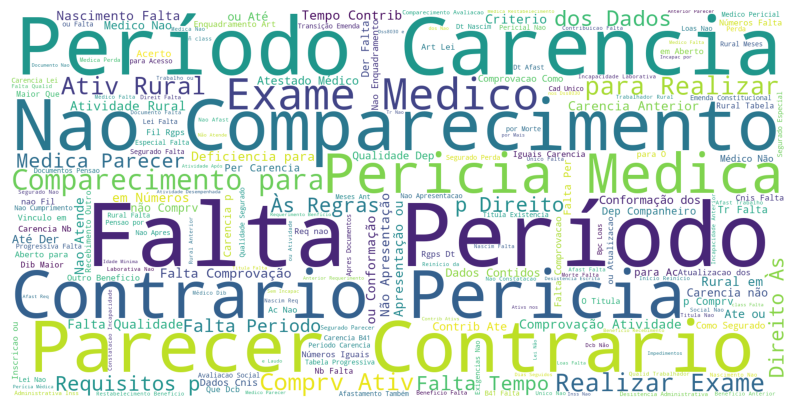

In [66]:
#lista de stopword
stopwords = set(STOPWORDS)
stopwords.update(['Zerados', 'de','ao'])

#gerar uma wordcloud
wordcloud = WordCloud(stopwords=stopwords,background_color='white',width=1600,height=800).generate(all_summary)

#mostrar a imagem final 
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(wordcloud, interpolation = 'bilinear')
ax.set_axis_off()

plt.imshow(wordcloud);
wordcloud.to_file('Motivo_indeferimento.png')

In [59]:
summaryze = concedidos_se.dropna(subset = ['Despacho'], axis = 0)['Despacho']

In [60]:
all_summaryze = ' '.join(s for s in summaryze)
print('Quantidade de palavras: {}'.format(len(all_summaryze)))

Quantidade de palavras: 4786408


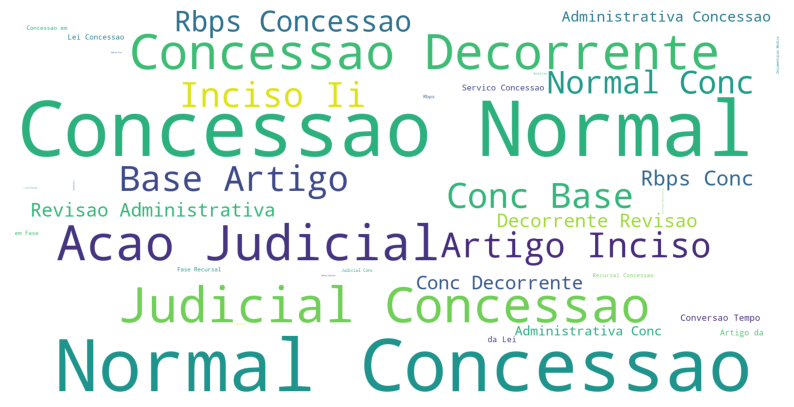

In [65]:
#lista de stopword
stopwords = set(STOPWORDS)
stopwords.update(['Zerados', 'de','ao', 'ñ class', 'class ñ','ñ','class'])

#gerar uma wordcloud
wordcloud = WordCloud(stopwords=stopwords,background_color='white',width=1600,height=800).generate(all_summaryze)

#mostrar a imagem final 
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(wordcloud, interpolation = 'bilinear')
ax.set_axis_off()

plt.imshow(wordcloud);
wordcloud.to_file('Motivo_concessao.png')

Terminada a limpeza e transformação dos dados, vamos para a análise dos dados

In [ ]:
beneficios.groupby(beneficios['Competência concessão'].dt.year)['Idade'].mean().plot.bar()

In [69]:
solicitados['Sexo'].value_counts()

Feminino     20615492
Masculino    15282157
Name: Sexo, dtype: int64

In [70]:
solicitados_se['Sexo'].value_counts()

Feminino     166127
Masculino    120127
Name: Sexo, dtype: int64

In [34]:
solicitados['Clientela'].value_counts()

Urbano    100647
Rural      44673
Name: Clientela, dtype: int64

In [55]:
sns.set_theme(style="whitegrid")

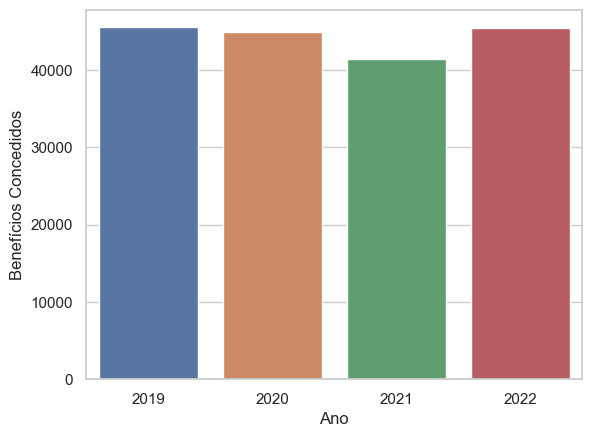

In [59]:
sns.countplot(x='Ano', data = beneficios_se)
plt.ylabel('Benefícios Concedidos')
plt.show()

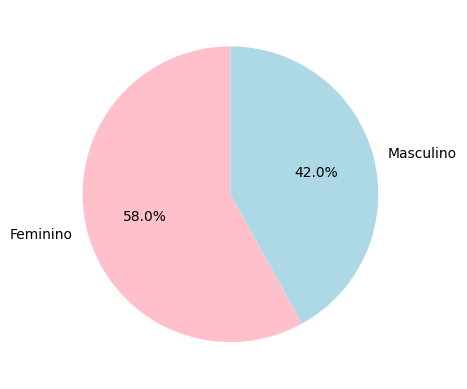

In [68]:
count = solicitados_se['Sexo'].value_counts().values
sexo = solicitados_se['Sexo'].value_counts().index
plt.pie(count, labels = list(sexo),startangle = 90,colors = ['pink','lightblue'],autopct='%1.1f%%')
plt.show()

In [1]:
sns.countplot(data=beneficios_se,x="Clientela")
plt.ylabel('Benefícios Concedidos')
plt.xlabel('')
plt.show()

NameError: name 'sns' is not defined

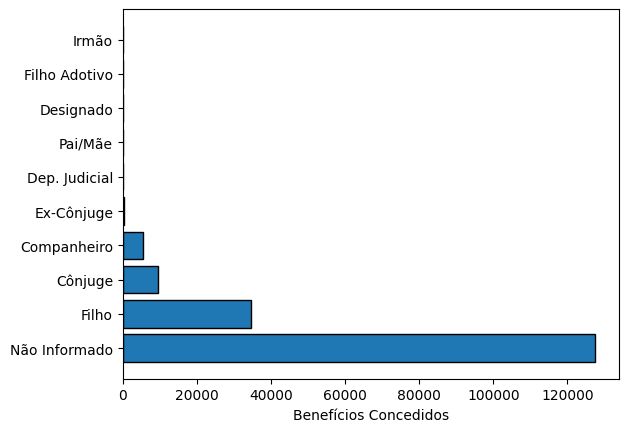

In [38]:
count2 = beneficios_se['Vínculo dependentes'].value_counts().values
index2 = beneficios_se['Vínculo dependentes'].value_counts().index
plt.barh(index2,count2,ec='k')
plt.xlabel('Benefícios Concedidos')
plt.ylabel('')
plt.show()

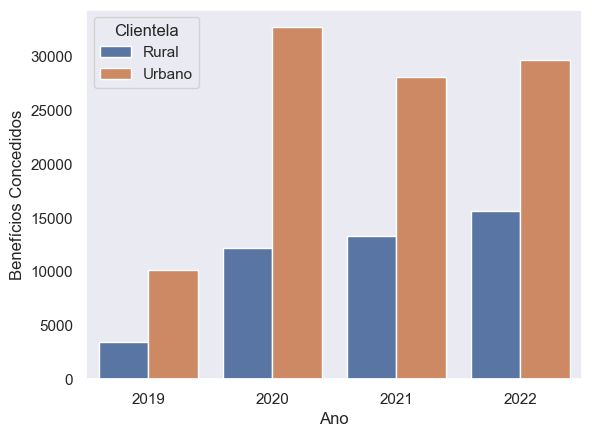

In [53]:
sns.countplot(x='Ano', data = beneficios_se,hue = 'Clientela')
plt.ylabel('Benefícios Concedidos')
plt.show()

In [76]:
beneficios_se.groupby('Ano').mean()

,Qt SM RMI,Idade
Ano,,
2019,1.180550,49.532465
2020,1.063754,48.387663
2021,1.121998,48.500507
2022,1.107876,47.385578


In [71]:
solicitados_se.groupby('Ano')['Espécie'].value_counts()

Ano                                             
2019  Auxílio Doença Previdenciário                 21460
      Aposentadoria por Idade                        9350
      Auxílio Salário Maternidade                    7492
      Pensão por Morte Previdenciária                7126
      Aposentadoria por Tempo de Contribuição        5319
      Aposentadoria por Invalidez Previdenciária     4728
      Auxílio Acidente do Trabalho                   1539
      Aposentadoria por Tempo de Serviço              463
      Aposentadoria Especial                          365
      Auxílio Reclusão                                302
2020  Auxílio Doença Previdenciário                 28849
      Aposentadoria por Idade                        9757
      Auxílio Salário Maternidade                    8519
      Pensão por Morte Previdenciária                7977
      Aposentadoria por Tempo de Contribuição        5725
      Aposentadoria Especial                         2041
      Aposentadoria por

In [72]:
solicitados['Espécie'].value_counts()

Auxílio Doença Previdenciário                 15989237
Aposentadoria por Idade                        5817614
Auxílio Salário Maternidade                    4922616
Aposentadoria por Tempo de Contribuição        3640926
Pensão por Morte Previdenciária                3202383
Auxílio Acidente do Trabalho                    873840
Aposentadoria por Invalidez Previdenciária      794578
Aposentadoria Especial                          345831
Auxílio Reclusão                                251852
Aposentadoria por Tempo de Serviço               58772
Name: Espécie, dtype: int64

In [73]:
solicitados_se['Espécie'].value_counts()

Auxílio Doença Previdenciário                 125014
Aposentadoria por Idade                        46936
Auxílio Salário Maternidade                    39489
Pensão por Morte Previdenciária                35836
Aposentadoria por Tempo de Contribuição        19022
Aposentadoria por Invalidez Previdenciária     10677
Auxílio Acidente do Trabalho                    4279
Aposentadoria Especial                          2875
Auxílio Reclusão                                1244
Aposentadoria por Tempo de Serviço               882
Name: Espécie, dtype: int64